In [1]:
# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



In [2]:
def create_square_plot(
    data: np.ndarray,
    classification: str | None = None,
    cmap: str = "coolwarm",
    title: str | None = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: bool | None = None,
):
    """
    Create a sorted amino acid × amino acid heatmap based on a chosen classification.

    Parameters
    ----------
    data : np.ndarray or pd.DataFrame
        Square matrix (e.g. 20x20) with values to plot.
    classification : str | None
        Key from AMINO_ACID_CLASSES (e.g. 'charge', 'polarity').
        If None, no sorting or group labeling is performed.
    cmap : str
        Matplotlib colormap.
    title : str | None
        Optional plot title.
    show_labels : bool
        Whether to display group labels (ignored if classification=None).
    figsize : tuple
        Figure size.
    return_fig : bool | None
        If True, return (fig, ax) instead of showing the plot.
        If None (default), just show the plot.
    """

    data = np.array(data)
    n = data.shape[0]
    if data.shape[0] != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    df = pd.DataFrame(data, index=aas, columns=aas)

    # === Case 1: no classification (no sorting or group labels) ===
    if classification is None:
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(df, cmap=cmap, square=True, cbar=True, ax=ax)

        if not title:
            title = "Amino acid × amino acid (unsorted)"
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Amino acid")
        ax.set_ylabel("Amino acid")

        plt.tight_layout()
        if return_fig:
            return fig, ax
        else:
            plt.show()
            return None

    # === Case 2: classification selected ===
    if classification not in AMINO_ACID_CLASSES:
        raise ValueError(f"Unknown classification: {classification}")

    groups = AMINO_ACID_CLASSES[classification]
    sorted_groups = list(groups.keys())

    sorted_aas = [aa for group in sorted_groups for aa in aas if aa in groups[group]]
    missing = [aa for aa in aas if aa not in sorted_aas]
    sorted_aas.extend(missing)

    df_sorted = df.loc[sorted_aas, sorted_aas]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax)

    if not title:
        title = f"Amino acid × amino acid ({classification} classification)"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Amino acid")
    ax.set_ylabel("Amino acid")

    # === Group boundaries and labels ===
    group_sizes = [len(groups[g]) for g in sorted_groups if any(aa in aas for aa in groups[g])]
    boundaries = np.cumsum(group_sizes)

    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=1)
        ax.axvline(b, color="black", lw=1)

    if show_labels:
        midpoints = np.array(boundaries) - np.array(group_sizes) / 2

        # Left-side (Y-axis)
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(-1.5, mid, g, va="center", ha="right", fontsize=10)

        # Bottom (X-axis)
        ylim = ax.get_ylim()
        xlim = ax.get_xlim()
        offset = len(aas) * 0.05
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(
                mid,
                len(aas) + offset,
                g,
                va="top",
                ha="center",
                fontsize=10,
                rotation=0,
            )
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)

    plt.tight_layout()

    if return_fig:
        return fig, ax
    else:
        plt.show()
        return None

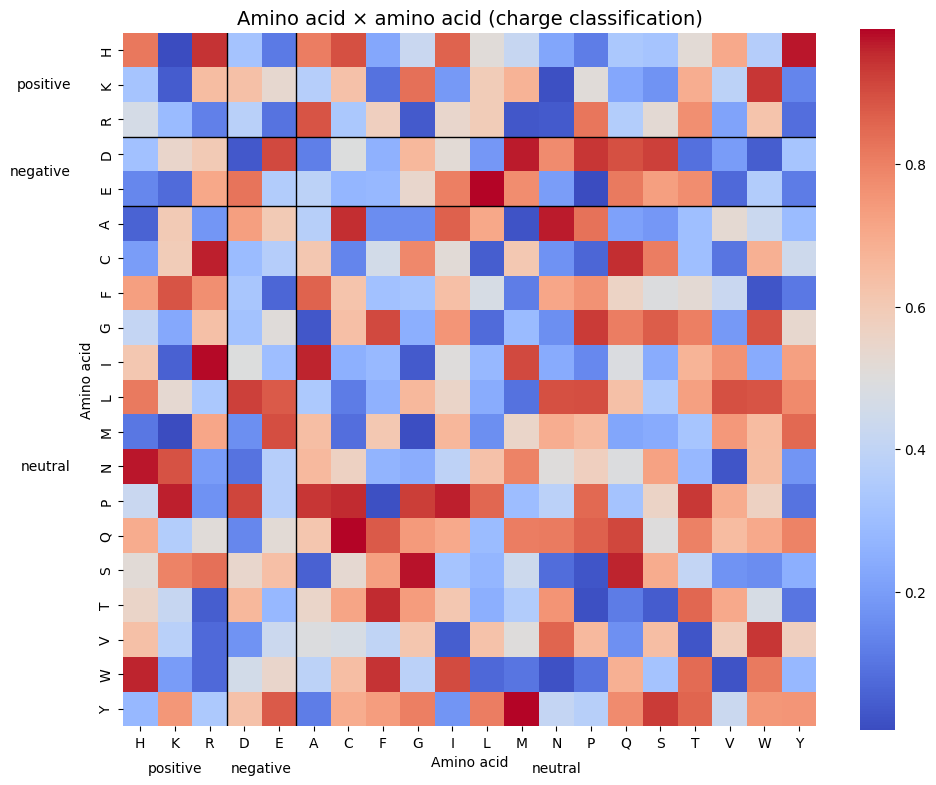

In [3]:
np.random.seed(42)
random_data = np.random.rand(20, 20)
create_square_plot(random_data, classification="charge")


In [4]:
##count number of changes of AA into AA and create matrix (except id)
from pathlib import Path

project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"


mutants = pd.read_csv(
    project_root
    / "results/data/mutants/veltri_negative/veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv"
)

In [5]:
import pandas as pd
import numpy as np

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

mutants_clean = mutants.dropna(subset=["parent", "mutant", "position"]).drop_duplicates()

## just filter out padding -> sth mutations
mask = (
    mutants_clean["position"] < mutants_clean["parent"].str.len()
) & (
    mutants_clean["position"] < mutants_clean["mutant"].str.len()
)
mutants_clean = mutants_clean[mask]


mask2 = (mutants_clean['parent'] != mutants_clean['mutant'])
mutants_clean = mutants_clean[mask2]
parent_aas = mutants_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
mutant_aas = mutants_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)


mutation_counts = (
    pd.DataFrame({"parent": parent_aas, "mutant": mutant_aas})
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=ALL_AA, columns=ALL_AA, fill_value=0)
)


In [6]:
mutation_counts

mutant,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
parent,,,,,,,,,,,,,,,,,,,,
A,0,28,214,53,27,468,4,53,163,151,337,69,53,85,65,318,122,55,118,29
C,10,0,7,13,306,26,262,88,33,87,4,45,42,6,20,20,47,102,2,34
D,739,30,0,519,45,448,20,47,146,223,46,99,20,35,26,776,69,157,47,24
E,174,49,812,0,50,158,70,100,238,2302,20,183,26,32,19,902,660,364,68,17
F,34,316,20,31,0,61,130,286,188,106,16,155,331,77,50,47,61,78,11,362
G,466,93,181,59,97,0,72,57,75,92,134,36,69,91,97,370,114,275,35,78
H,12,367,3,14,242,57,0,373,37,154,17,38,41,45,46,36,293,448,6,45
I,76,137,28,43,502,86,490,0,238,668,32,411,434,98,31,108,344,108,49,29
K,152,40,66,64,94,75,26,115,0,185,32,198,200,382,67,140,133,49,440,125


In [7]:

np.fill_diagonal(mutation_counts.values, 0)
mutation_counts = mutation_counts.div(mutation_counts.sum(axis=1), axis=0).fillna(0)


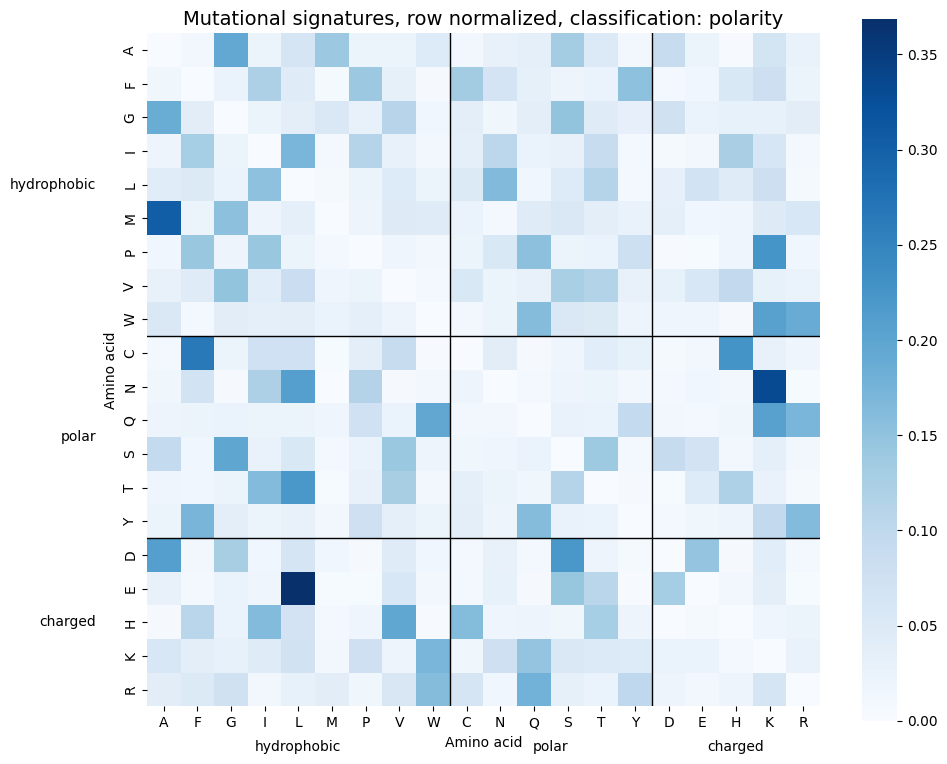

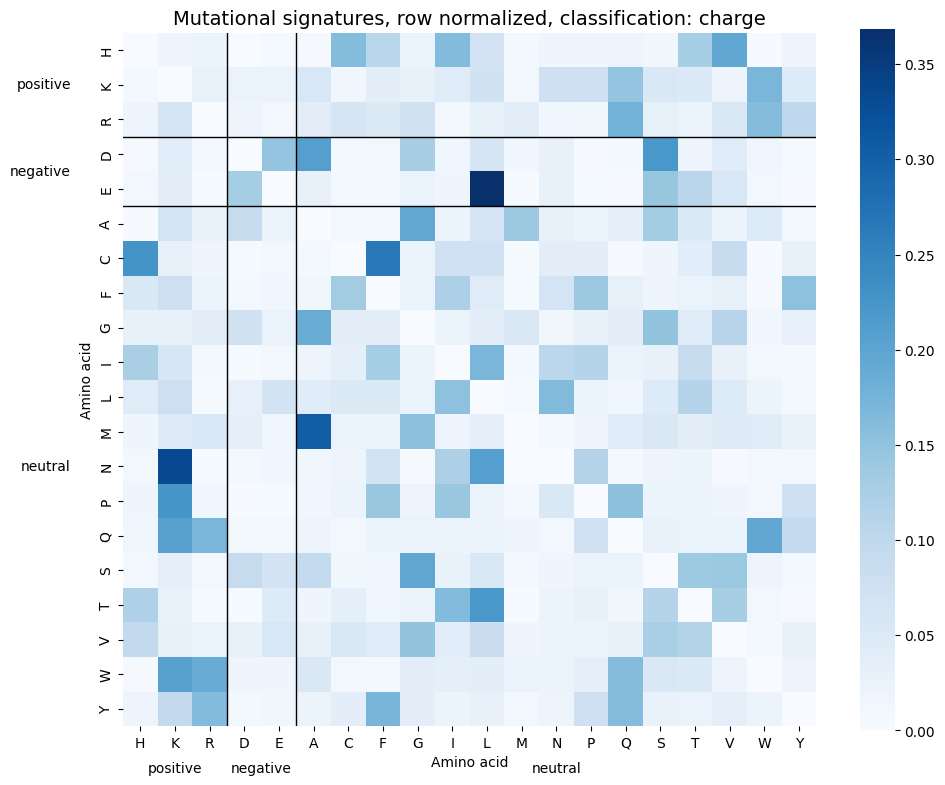

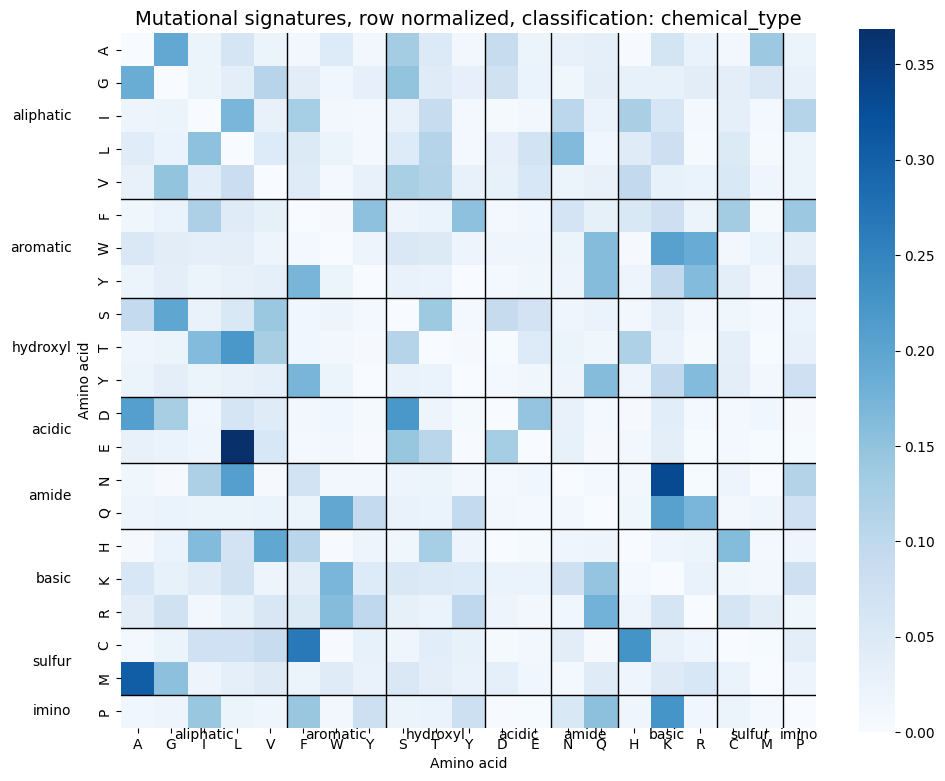

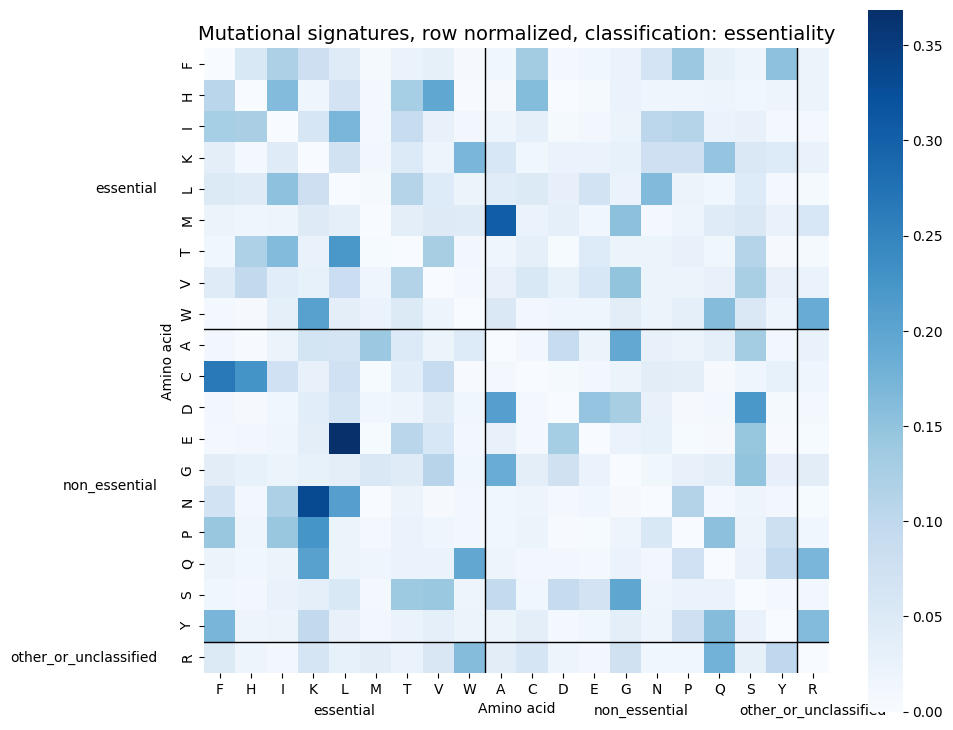

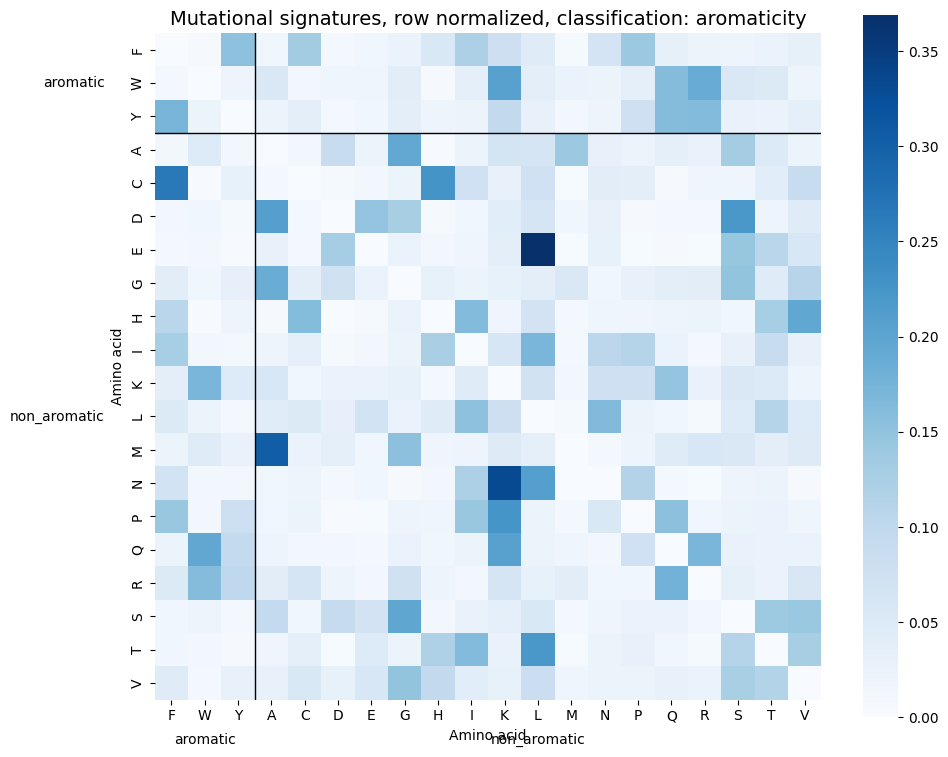

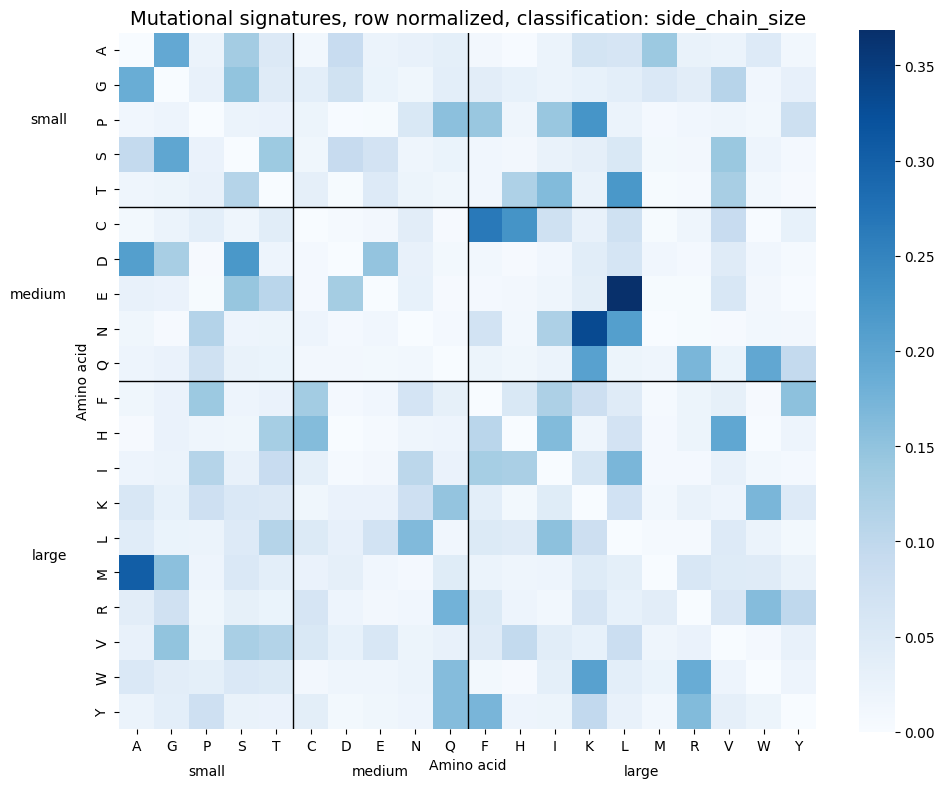

In [8]:



for c in classes:
    create_square_plot(
        mutation_counts.values,
        classification=c,
        cmap="Blues",
        title=f"Mutational signatures, row normalized, classification: {c}",
        show_labels=True,
        # figsize=(10, 8),
    )

Now positive

In [9]:
##count number of changes of AA into AA and create matrix (except id)
from pathlib import Path

project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"


mutants = pd.read_csv(
    project_root
    / "results/data/mutants/veltri_positive/veltri_positive_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv"
)

In [10]:
import pandas as pd
import numpy as np

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

mutants_clean = mutants.dropna(subset=["parent", "mutant", "position"]).drop_duplicates()

## just filter out padding -> sth mutations
mask = (
    mutants_clean["position"] < mutants_clean["parent"].str.len()
) & (
    mutants_clean["position"] < mutants_clean["mutant"].str.len()
)
mutants_clean = mutants_clean[mask]


mask2 = (mutants_clean['parent'] != mutants_clean['mutant'])
mutants_clean = mutants_clean[mask2]
parent_aas = mutants_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
mutant_aas = mutants_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)


mutation_counts = (
    pd.DataFrame({"parent": parent_aas, "mutant": mutant_aas})
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=ALL_AA, columns=ALL_AA, fill_value=0)
)


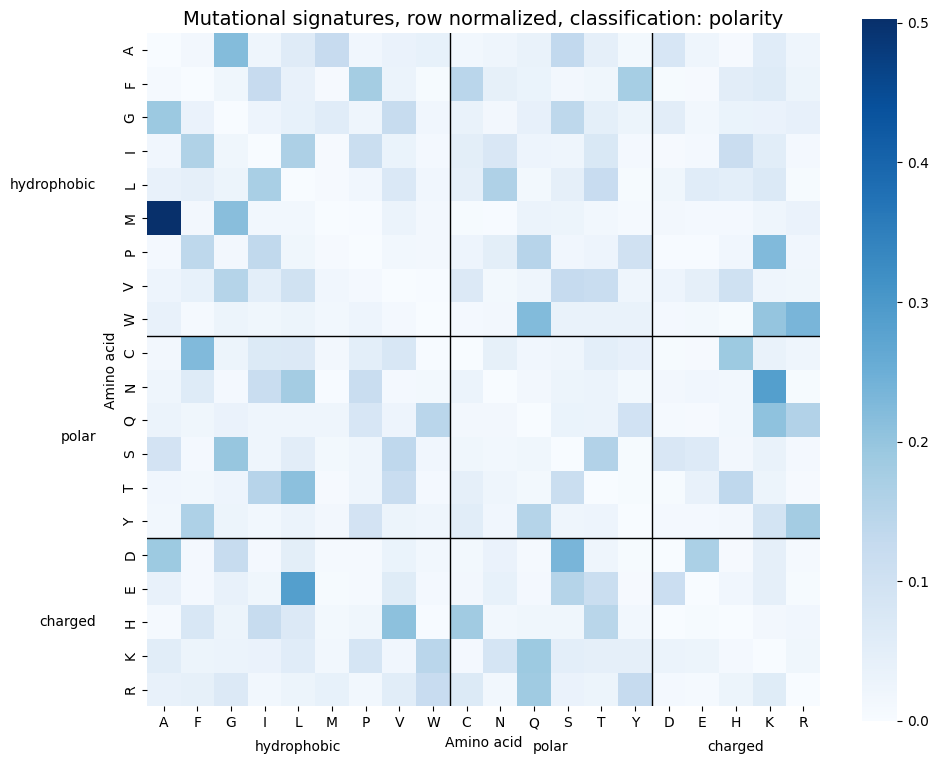

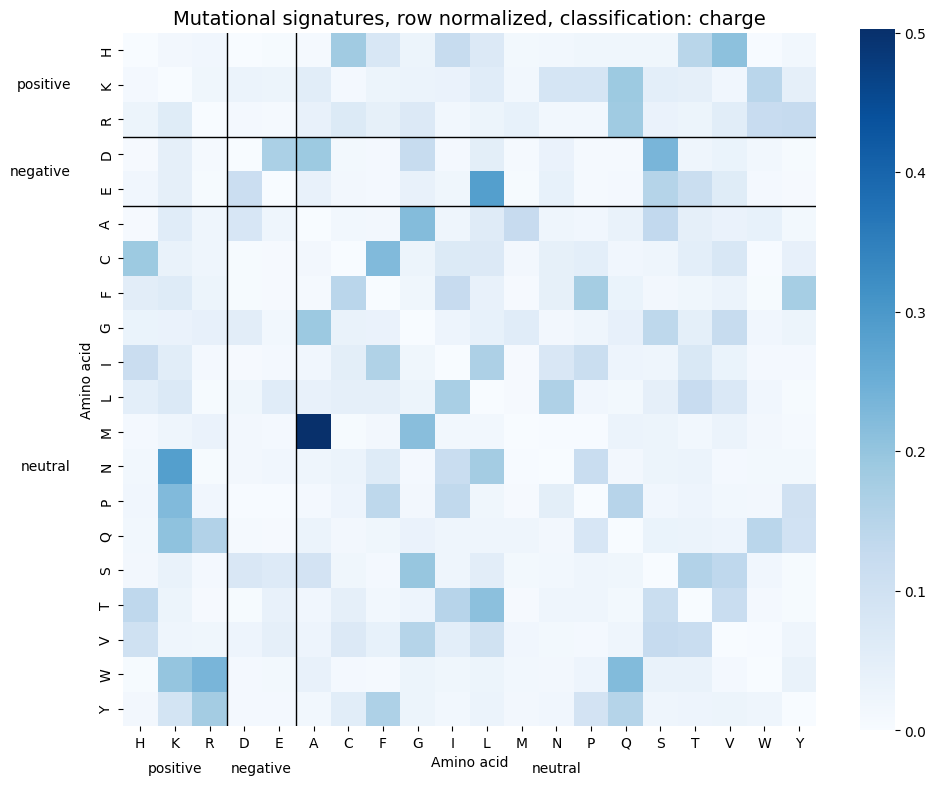

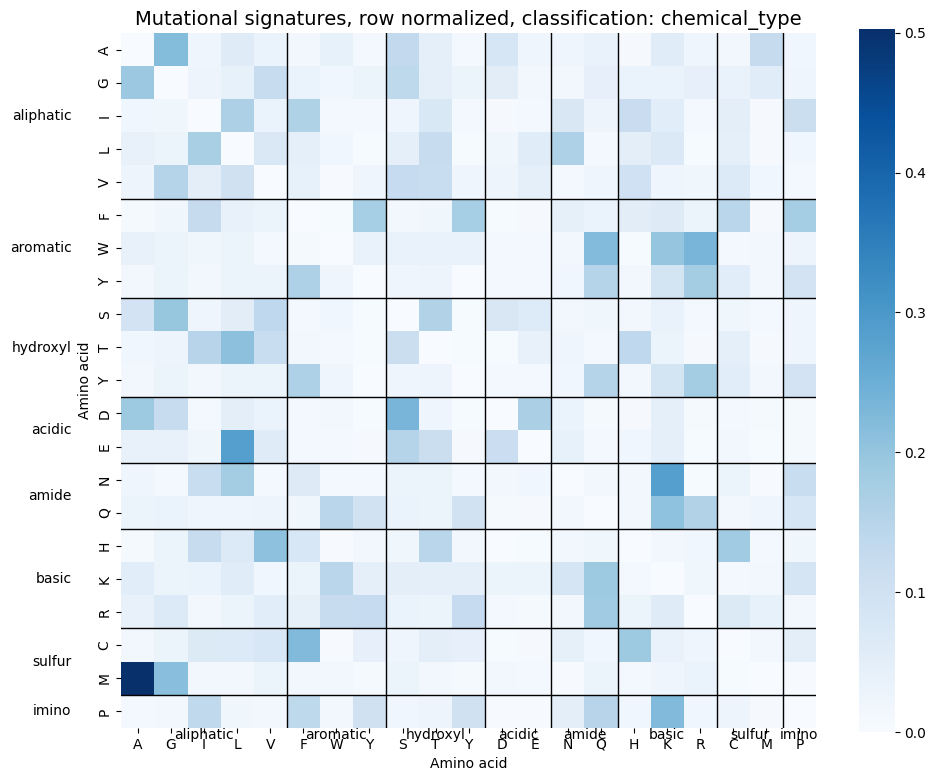

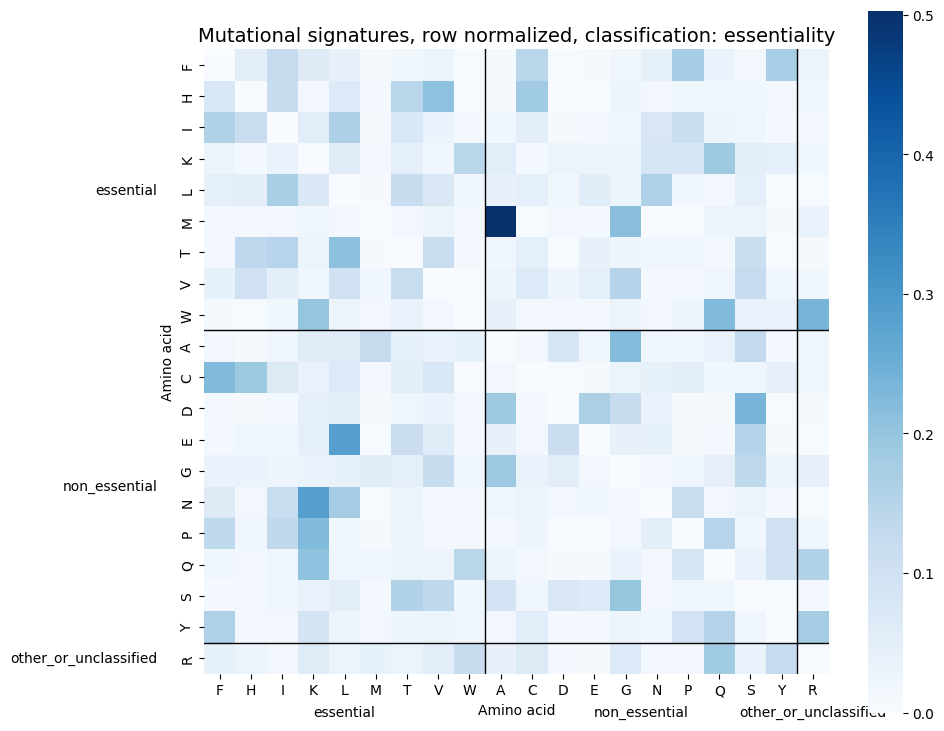

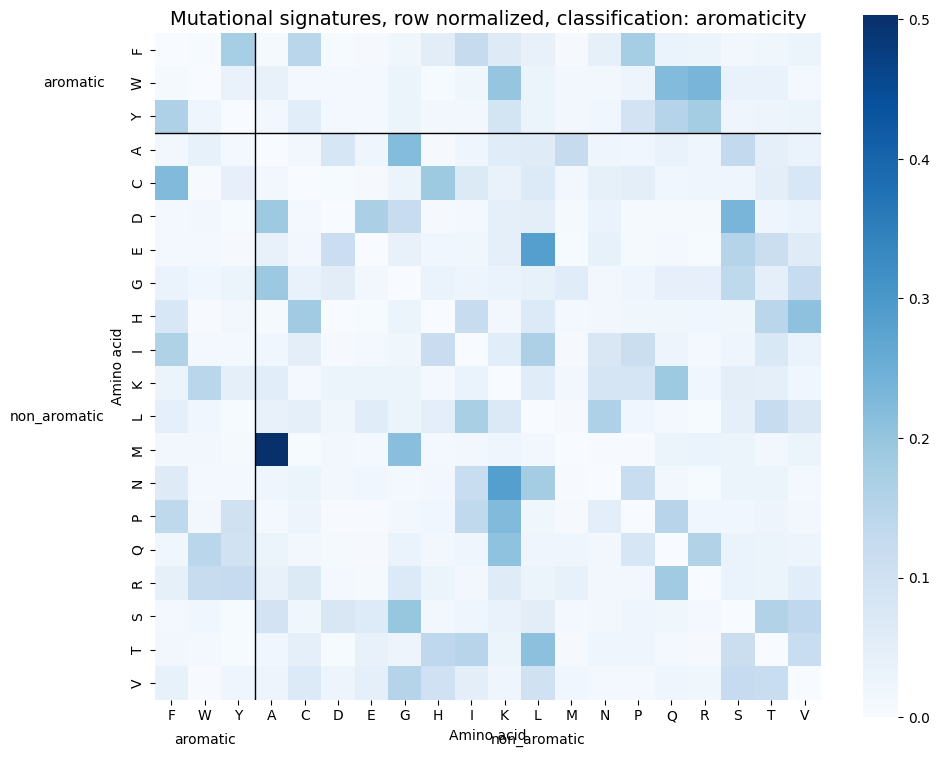

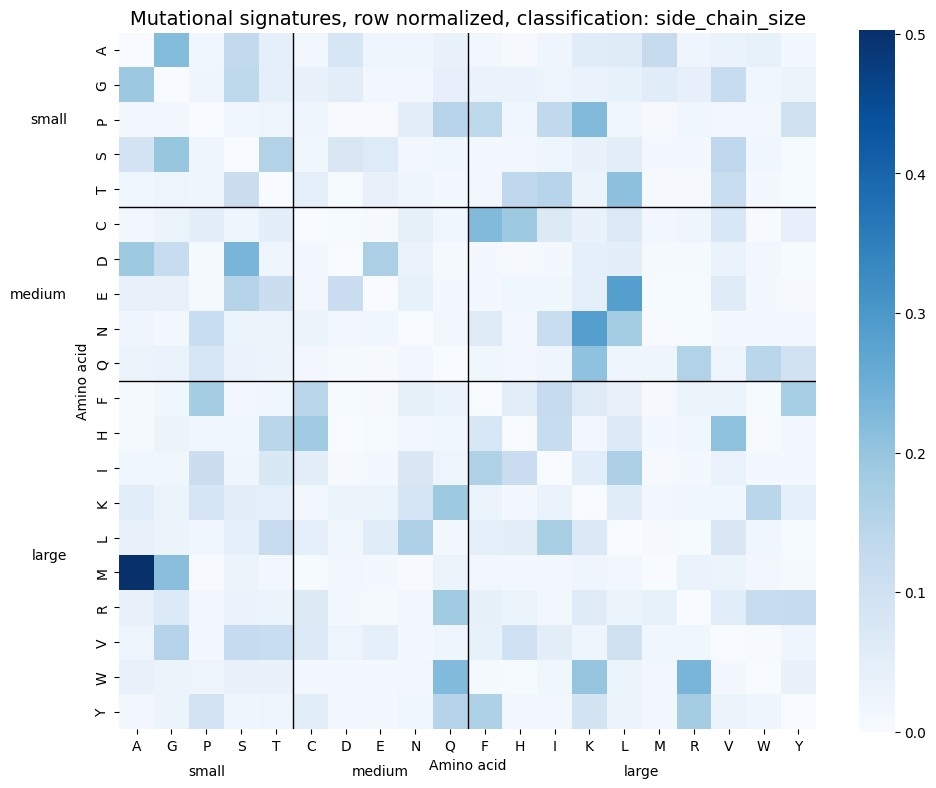

In [11]:
np.fill_diagonal(mutation_counts.values, 0)
mutation_counts = mutation_counts.div(mutation_counts.sum(axis=1), axis=0).fillna(0)


for c in classes:
    create_square_plot(
        mutation_counts.values,
        classification=c,
        cmap="Blues",
        title=f"Mutational signatures, row normalized, classification: {c}",
        show_labels=True,
        # figsize=(10, 8),
    )